In [1]:
import os
import warnings
import logging

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['KMP_WARNINGS'] = '0'

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

logging.getLogger('absl').setLevel(logging.ERROR)

import tensorflow as tf
import keras

for g in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(g, True)

tf.keras.utils.set_random_seed(0)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)
print("Built with CUDA:", tf.test.is_built_with_cuda())

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA: True


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Lasso, BayesianRidge, RidgeCV, Ridge
from sklearn.svm import SVR, LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, StackingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

from tensorflow.keras.layers import BatchNormalization, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import R2Score, MAE, MAPE
from tensorflow.keras.regularizers import l2
from sklearn.compose import TransformedTargetRegressor
from scikeras.wrappers import KerasRegressor

from utils import _get_metrics, model_metrics_barplot, show_final_history, plot_pred_vs_true,  plot_residuals_hist

import sklearn

# Enable pandas output globally
sklearn.set_config(transform_output="pandas")

In [3]:
data = pd.read_excel('../data/Folds5x2_pp.xlsx')
data.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


## Baseline Models Performance Analysis

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    data.drop('PE', axis=1),
    data['PE'],
    test_size=0.3,
    random_state=0
)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


lin_models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(alpha=1e-3, max_iter=20000, random_state=0),
    'Bayesian Ridge': BayesianRidge(max_iter=300, tol=1e-4),
    'Linear SVR': LinearSVR(C=1.0, epsilon=0.1, loss='epsilon_insensitive', dual='auto', max_iter=20000, random_state=0),
    'SVR (RBF)': SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale'),
    'Neighbors': KNeighborsRegressor(n_neighbors=15, weights='uniform', p=2)
} 

tree_models = {
    'DecisionTree': DecisionTreeRegressor(max_depth=6, min_samples_leaf=2, random_state=0),
    'RandomForest': RandomForestRegressor(n_estimators=300, min_samples_leaf=2, max_features='sqrt', random_state=0, n_jobs=-1),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=500, min_samples_leaf=2, max_features='sqrt', bootstrap=False, random_state=0, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=0),
    'XGB': XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, tree_method='hist', random_state=0, n_jobs=-1),
    'CatBoost': CatBoostRegressor(iterations=800, learning_rate=0.05, depth=6, loss_function='RMSE', random_state=0, verbose=False, allow_writing_files=False)    
}

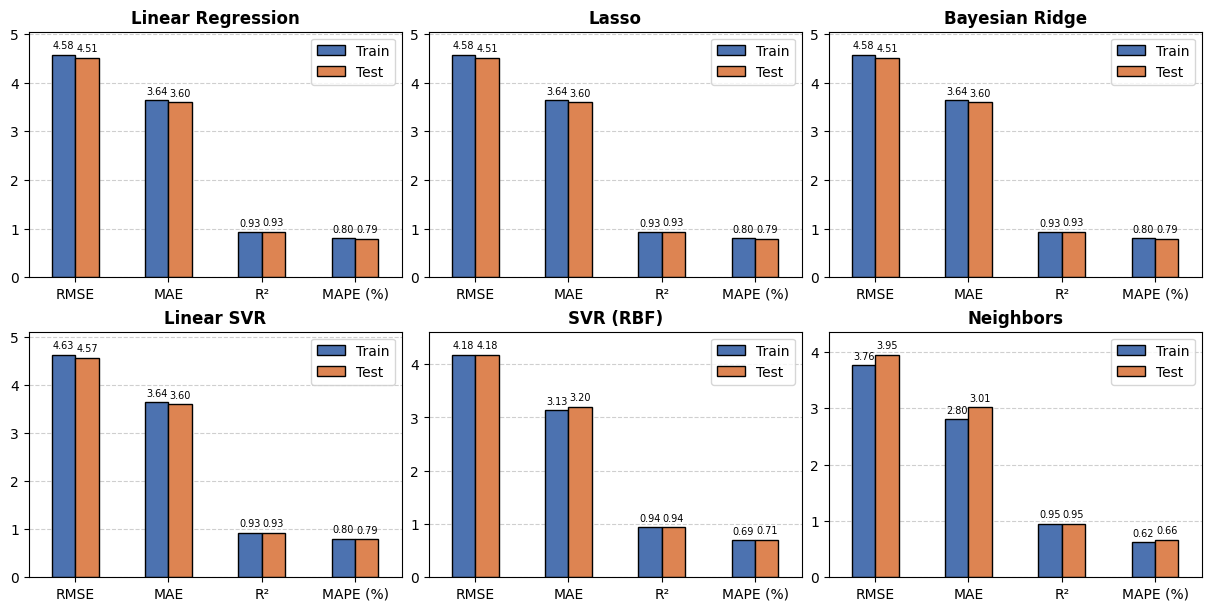

In [6]:
# Setup grid
cols = min(3, len(lin_models))
rows = math.ceil(len(lin_models) / cols) 

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3), squeeze=False, constrained_layout=True)

# Plotting 
for ax, (name, model) in zip(axes.flat, lin_models.items()):
    model.fit(X_train_scaled, y_train)
    model_metrics_barplot(name, model, X_train_scaled, y_train, X_test_scaled, y_test, ax=ax, barlabel_siaze=7)

for ax in axes.flat[len(lin_models):]:
    ax.remove()

plt.show()

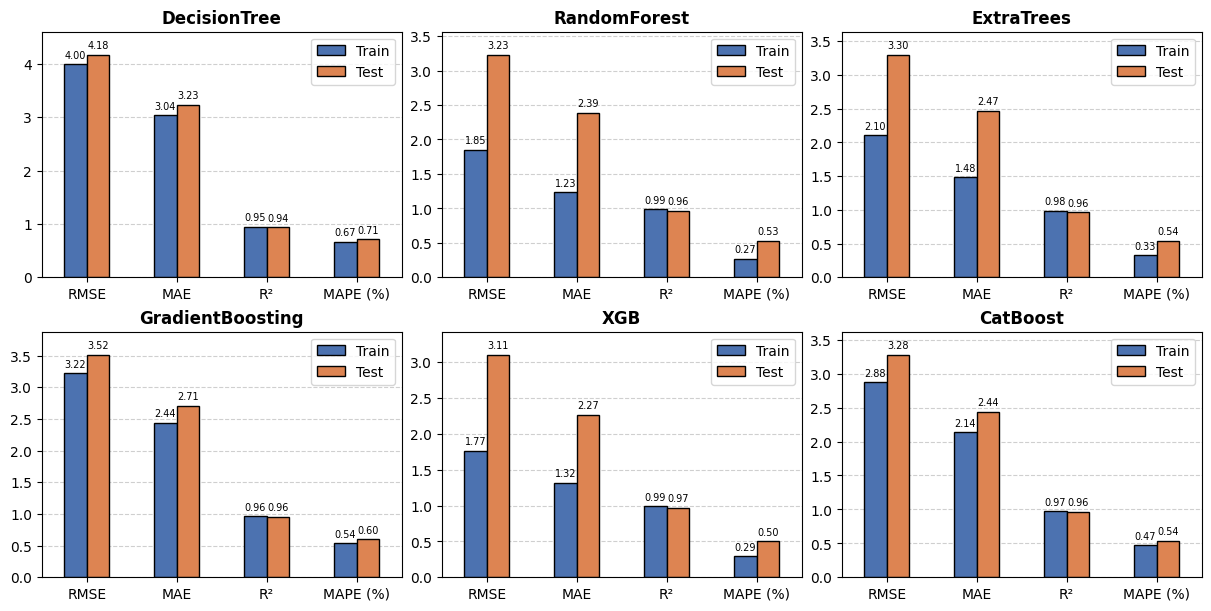

In [7]:
# Setup grid
cols = min(3, len(tree_models))
rows = math.ceil(len(tree_models) / cols) 

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3), squeeze=False, constrained_layout=True)

# Plotting 
for ax, (name, model) in zip(axes.flat, tree_models.items()):
    model.fit(X_train, y_train)
    model_metrics_barplot(name, model, X_train, y_train, X_test, y_test, ax=ax, barlabel_siaze=7)

for ax in axes.flat[len(tree_models):]:
    ax.remove()

plt.show()

* The data exhibits a clearly non-linear nature.
* Linear models are stable, but tree-based ensemble models show better metrics on the test set.
* However, the gap between the training and test sets is smaller for linear models.
* The top performers are `XGBoost` and `CatBoost`.

## Performance Analysis of Models After GridSearch

In [8]:
param_grid_svr = {
    'C': [1, 5, 10, 50],
    'epsilon': [0.01, 0.1, 0.3],
    'gamma': ['scale', 'auto', 0.1, 0.01]
}

param_grid_neighbors = {
    'n_neighbors': [5, 10, 15, 25, 35],
    'weights': ['uniform'],
    'p': [1, 2]
}

param_grid_rf = {
    'max_depth': [None, 12, 24],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.8]
}

param_grid_gb = {
    'n_estimators': [300, 500],
    'learning_rate': [0.03, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

param_grid_xgb = {
    'n_estimators': [400, 500],
    'learning_rate': [0.03, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

param_grid_cb = {
    'iterations': [400, 500],
    'learning_rate': [0.03, 0.1],
    'depth': [4, 6, 8] 
}

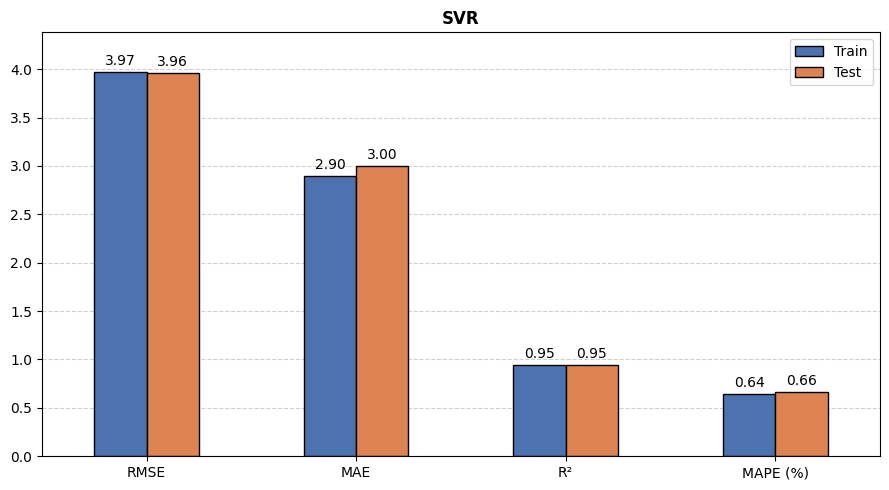

SVR (RBF) Best params:  {'C': 50, 'epsilon': 0.3, 'gamma': 'scale'}


In [9]:
grid_svr = GridSearchCV(estimator=SVR(kernel='rbf'), param_grid=param_grid_svr, scoring='r2', cv=5, n_jobs=-1)
grid_svr.fit(X_train_scaled, y_train)
model_metrics_barplot("SVR", grid_svr, X_train_scaled, y_train, X_test_scaled, y_test)
print('SVR (RBF) Best params: ', grid_svr.best_params_)

**SVR (RBF)**: High stability (almost no difference between training and test sets).

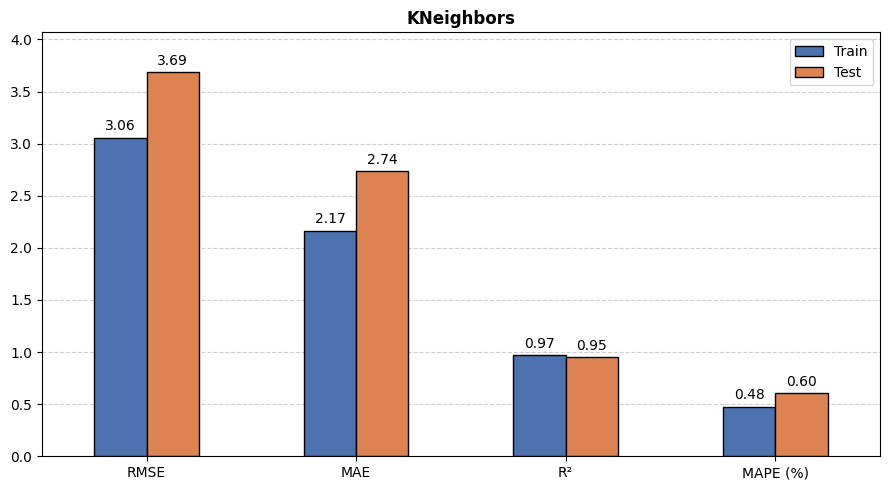

SVR (RBF) Best params:  {'n_neighbors': 5, 'p': 1, 'weights': 'uniform'}


In [10]:
grid_neighbors = GridSearchCV(estimator=KNeighborsRegressor(), param_grid=param_grid_neighbors, scoring='r2', cv=5, n_jobs=-1)
grid_neighbors.fit(X_train_scaled, y_train)
model_metrics_barplot("KNeighbors", grid_neighbors, X_train_scaled, y_train, X_test_scaled, y_test)
print('SVR (RBF) Best params: ', grid_neighbors.best_params_)

**KNeighbors**: A good baseline algorithm, the result on the test set is higher than that of `SVR`.

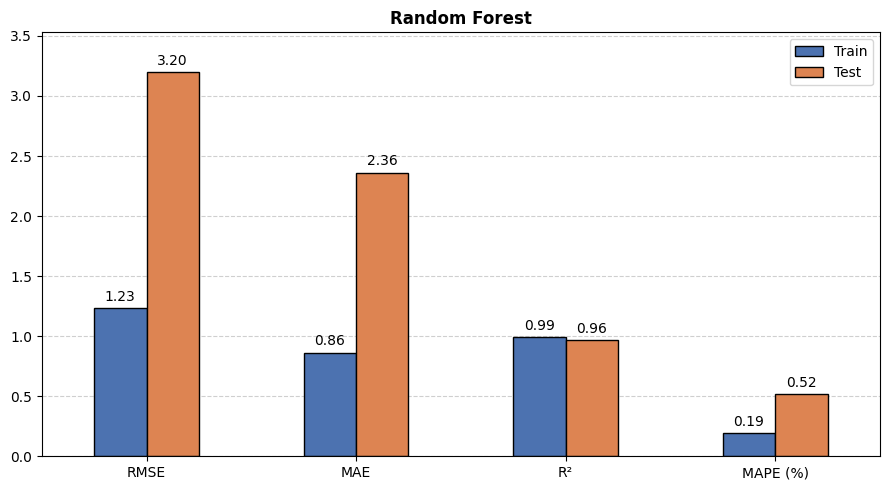

Best params:  {'max_depth': 24, 'max_features': 'sqrt', 'min_samples_leaf': 1}


In [11]:
grid_rf = GridSearchCV(estimator=RandomForestRegressor(n_estimators = 300, random_state=0), param_grid=param_grid_rf, scoring='r2', cv=5, n_jobs=-1)
grid_rf.fit(X_train, y_train)
model_metrics_barplot("Random Forest", grid_rf, X_train, y_train, X_test, y_test)
print('Best params: ', grid_rf.best_params_)

**Random Forest**:

* GridSearch selected a high tree depth.
* The model memorized the training set.
* Although the gap between the training and test sets is larger than for the previous algorithms, the result on the training set is better!

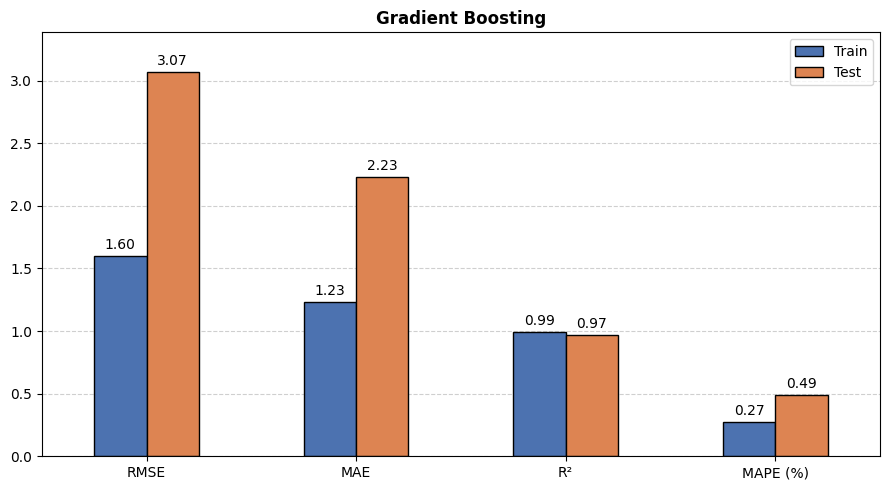

GradientBoosting Best params:  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.8}


In [12]:
grid_gb = GridSearchCV(estimator=GradientBoostingRegressor(random_state=0), param_grid=param_grid_gb, scoring='r2', cv=5, n_jobs=-1)
grid_gb.fit(X_train, y_train)
model_metrics_barplot("Gradient Boosting", grid_gb, X_train, y_train, X_test, y_test)
print('GradientBoosting Best params: ', grid_gb.best_params_)

**Gradient Boosting**:

* The winner by absolute metrics.
* Showed the lowest `RMSE` on the test set ($3.07$) and an excellent R2 ($0.97$).
* However, a (non-critical) imbalance in metrics (Train is twice as good as Test) still remains.

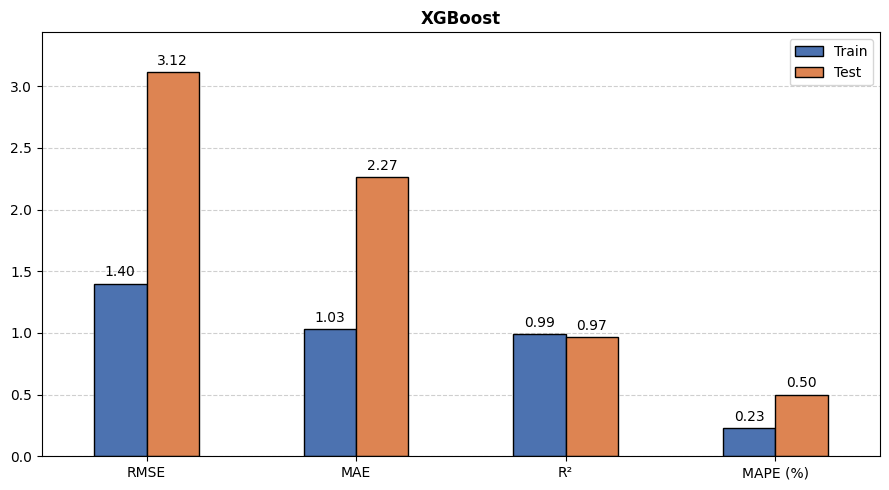

XGBoost Best params:  {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 500, 'subsample': 1.0}


In [13]:
grid_xgb = GridSearchCV(estimator=XGBRegressor(random_state=0), param_grid=param_grid_xgb, scoring='r2', cv=5, n_jobs=7)
grid_xgb.fit(X_train, y_train)
model_metrics_barplot("XGBoost", grid_xgb, X_train, y_train, X_test, y_test)
print('XGBoost Best params: ', grid_xgb.best_params_)

**XGBoost**: Performed slightly worse than `GradientBoostingRegressor` (Test `RMSE` $3.12$).

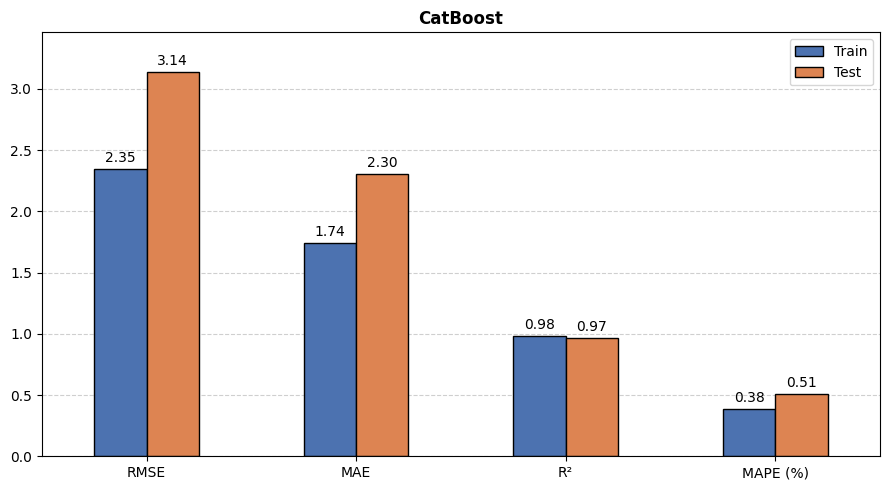

CatBoost Best params:  {'depth': 8, 'iterations': 500, 'learning_rate': 0.1}


In [14]:
grid_cb = GridSearchCV(
    estimator=CatBoostRegressor(random_state=0, verbose=False, allow_writing_files=False), 
    param_grid=param_grid_cb, 
    scoring='r2', 
    cv=5, 
    n_jobs=-1
)

grid_cb.fit(X_train, y_train)
model_metrics_barplot("CatBoost", grid_cb, X_train, y_train, X_test, y_test)
print('CatBoost Best params: ', grid_cb.best_params_)

**CatBoost**:
* The leader in balancing robustness and performance.
* The gap between Train ($2.35$) and Test ($3.14$) is the smallest among all powerful ensembles.
* The model achieved an excellent balance.

**Overall Conclusion**:
* `GridSearch` allowed us to achieve excellent metrics (`R2` reached $0.97$).
* As expected, boosting algorithms dominate.
* `GradientBoosting` yielded the absolute minimum error on the test set.
* `CatBoost` demonstrated the best generalization ability: the algorithm managed to maintain the minimal delta between the metrics on the training and test sets.

## Analysis of the Fully Connected Neural Network (FNN)

In [15]:
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

In [16]:
model = Sequential()
model.add(Input(shape=(X_train_scaled.shape[1],)))
#model.add(BatchNormalization())

model.add(Dense(512, activation='relu', kernel_regularizer=l2(1e-6)))
model.add(Dropout(0.1))
model.add(Dense(512, activation='relu', kernel_regularizer=l2(1e-5)))
#model.add(Dropout(0.1))
model.add(Dense(64, activation='relu')) 
#model.add(Dropout(0.1))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=[MAE, R2Score]) 

I0000 00:00:1783425986.049432  797035 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13689 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


In [17]:
cb = [
    #EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.6, patience=10, min_lr=1e-6)]

history = model.fit(
    X_train_scaled, 
    y_train_scaled,
    validation_split=0.15,
    epochs=300,
    batch_size=128,
   # shuffle=True,
    callbacks=cb,
    verbose=0
)

I0000 00:00:1783425990.172849  798217 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


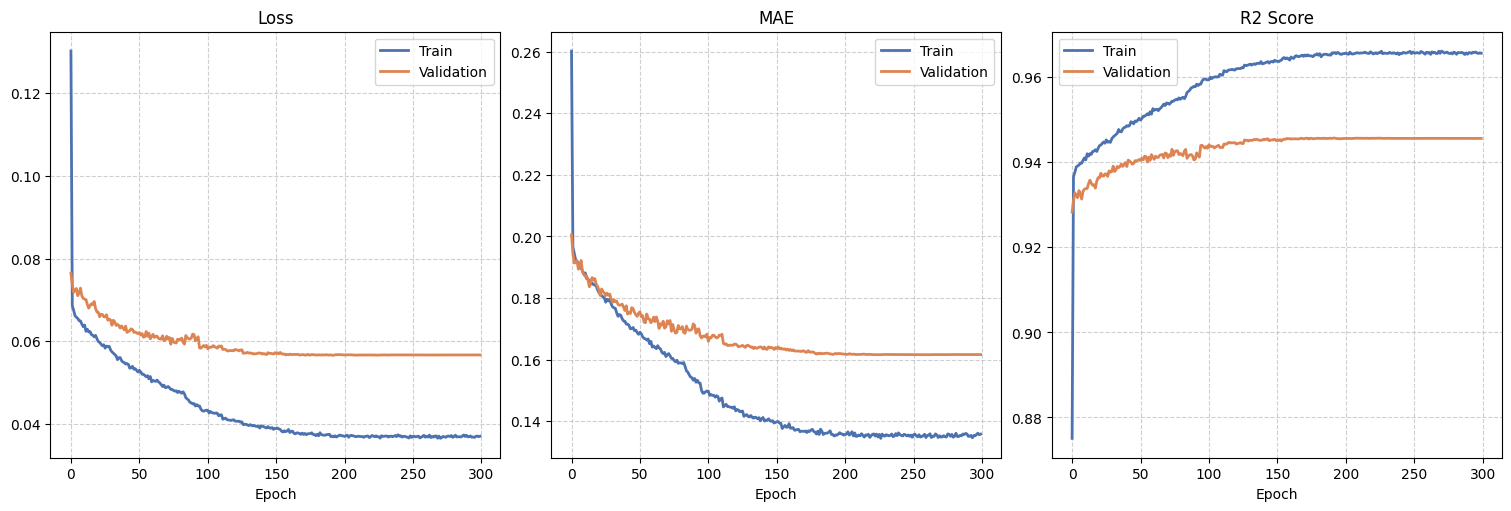

In [18]:
show_final_history(history)

* The `Loss` and `MAE` plots clearly show that the validation error reaches its minimum and stops improving after epochs $100-120$.
* Meanwhile, the blue line (Train) continues to decrease right up to the $300th$ epoch.
* The network begins to memorize the micro-noise of the training set.

210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


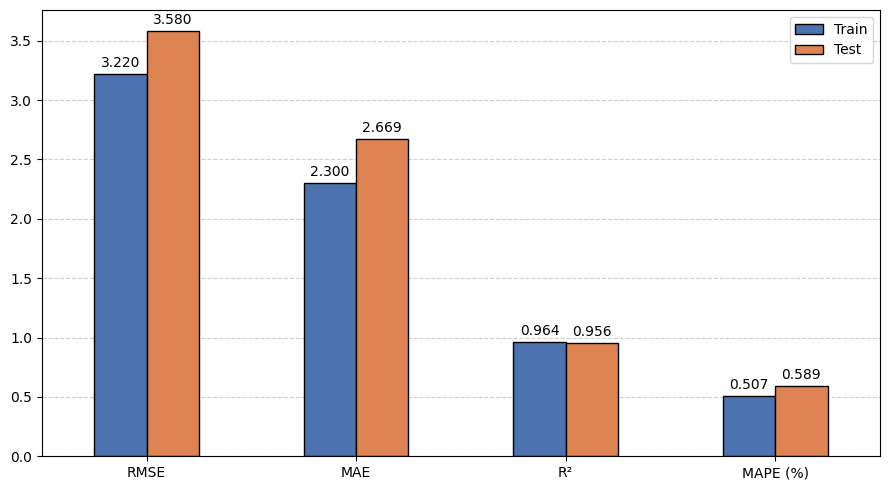

In [19]:
# Get predictions and inverse transform
y_pred_train = y_scaler.inverse_transform(model.predict(X_train_scaled))
y_pred_test = y_scaler.inverse_transform(model.predict(X_test_scaled))

# Bind metrics to a DataFrame
df_metrics = pd.DataFrame({
    "Train": _get_metrics(y_train, y_pred_train),
    "Test": _get_metrics(y_test, y_pred_test)
})

ax = df_metrics.plot.bar(figsize=(9, 5), rot=0, edgecolor='black', color=sns.color_palette("deep").as_hex())
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle='--', alpha=0.6)

for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

* The model demonstrated high accuracy (`R2` $= 0.955$, `MAPE` $= 0.602\%$ on the test set).
* In absolute terms, the gap between Train and Test is minimal ($<1\%$),
* which is characteristic of electricity data with its structural homogeneity.

## Performance Analysis of the Meta-Model (Super Learner / Stacking)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    data.drop('PE', axis=1),
    data['PE'],
    test_size=0.3,
    random_state=0
)

In [21]:
nn_model = Sequential()
nn_model.add(Input(shape=(X_train.shape[1],)))

nn_model.add(Dense(512, activation='relu', kernel_regularizer=l2(1e-6)))
nn_model.add(Dropout(0.1))
nn_model.add(Dense(512, activation='relu', kernel_regularizer=l2(1e-5)))
nn_model.add(Dense(64, activation='relu'))
nn_model.add(Dense(1))

In [22]:
keras_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KerasRegressor(
        model=nn_model,
        optimizer='adam',
        loss='mse',
        metrics=[MAE, R2Score],
        epochs=300, batch_size=128,
        callbacks=[ReduceLROnPlateau(monitor='val_loss', factor=0.6, patience=10, min_lr=1e-6)],
        validation_split=0.15,
        random_state=0,
        verbose=0
    ))
])

nn_scaled = TransformedTargetRegressor(
    regressor=keras_pipe,
    transformer=StandardScaler()
)

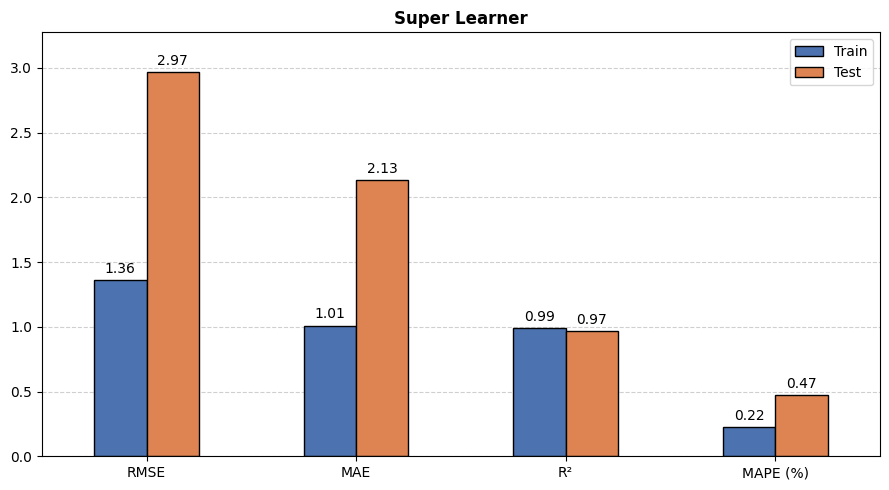

In [23]:
estimators = [

    ('svr', make_pipeline(StandardScaler(), SVR(kernel='rbf', C=50, epsilon=0.3, gamma='scale'))),
    ('neighbors', make_pipeline(MinMaxScaler(), KNeighborsRegressor(n_neighbors=5, p=1, weights='uniform'))),
    ('RF', RandomForestRegressor(n_estimators = 300, max_depth=24, max_features='sqrt', min_samples_leaf=1, random_state=0)),
    #("GB", GradientBoostingRegressor(learning_rate=0.1, max_depth=5, n_estimators=500, subsample=0.8)),
    ('XGB', XGBRegressor(colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=6, min_child_weight=1, n_estimators=1000, reg_alpha=0.0, reg_lambda=2.0, subsample=0.9, random_state=0)),
    ('CatBoost', CatBoostRegressor(depth=8, iterations=1000, l2_leaf_reg=3, leaf_estimation_iterations=2, learning_rate=0.1, verbose=False)),
    ('nn', nn_scaled)
]

final_estimator = make_pipeline(
    RidgeCV(alphas=[1e-4, 1e-3, 1e-2, 0.1, 1.0, 10.0])
)

super_learner = StackingRegressor(estimators=estimators, final_estimator=final_estimator, passthrough=True, cv=5)

super_learner.fit(X_train, y_train)
model_metrics_barplot("Super Learner", super_learner, X_train, y_train, X_test, y_test)

**Ensemble Architecture Breakdown and Metrics Analysis**

* **Diversity:** Models of different mathematical natures are gathered in `estimators`. Scale-sensitive algorithms are wrapped in pipelines with scalers (`StandardScaler`, `MinMaxScaler`).
* **Smart Meta-Algorithm:** Using `RidgeCV` as the `final_estimator` is a classic and the most reliable solution for stacking. A linear model with L2 regularization handles multicollinearity perfectly (the predictions of base models are highly correlated).
* **Passthrough=True:** The meta-model takes as input not only the predictions of the base algorithms but also the original features.
* **Global Error Minimum:** The test `RMSE` dropped to $2.97$ (for the best single boosting models, it was $>3.05$), and `MAPE` set a new minimum at $0.47\%$.

---

**Overall Conclusion:** Combining diverse algorithms (trees, a neural network, SVR, and KNN) under the control of a linear meta-model made it possible to break through the quality "ceiling" of single models and set a new performance record on the test data.

## Analysis of Model Weights in the Ensemble

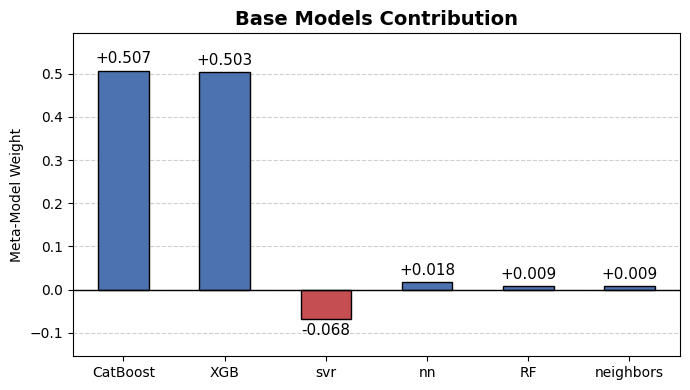

In [24]:
# Extract data
names = [n for n, _ in estimators]
all_coefs = super_learner.final_estimator_.named_steps["ridgecv"].coef_.ravel()
coefs = all_coefs[:len(names)]

# Bind to Pandas and sort by absolute magnitude
coef_series = pd.Series(coefs, index=names).sort_values(key=np.abs, ascending=False)

# Plotting
ax = coef_series.plot.bar(
    figsize=(7, 4), 
    color=['#4C72B0' if x >= 0 else '#C44E52' for x in coef_series],
    edgecolor='black',
    rot=0  
)

# Styling and Labels
ax.set_ylabel("Meta-Model Weight")
ax.set_title("Base Models Contribution", fontweight='bold', fontsize=14)
ax.axhline(0, color='black', linewidth=1)
ax.bar_label(ax.containers[0], fmt='%+.3f', padding=3, fontsize=11)
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle='--', alpha=0.6)

ax.margins(y=0.15)

plt.tight_layout()
plt.show()

* `CatBoost` and `XGBoost` shared the responsibility for the final prediction almost equally.
* The `SVR` algorithm received a small negative weight.
* The meta-model uses `SVR` predictions as an error corrector (compensator).
* If the boosting algorithms (`CatBoost`/`XGBoost`) tend to systematically overestimate the prediction in certain situations, `Ridge` subtracts the `SVR` portion to balance the output and bring it closer to reality.
* The neural network, Random Forest, and K-Nearest Neighbors received microscopic weights.
* The meta-model with L2 regularization recognized that these models either fall short in accuracy or their correct predictions entirely duplicate the answers of CatBoost and XGBoost.
* Keeping them in the ensemble is mathematically pointless.

---

**Overall Conclusion**: The meta-model (`Ridge`) delegated almost $100\%$ of the decision-making to two algorithms: `CatBoost` and `XGBoost`. Most of the other models turned out to be redundant: their predictions did not bring any new unique information to the ensemble, so the algorithm reduced their influence to virtually zero.

In [25]:
y_pred_train = super_learner.predict(X_train)
y_pred_test = super_learner.predict(X_test)

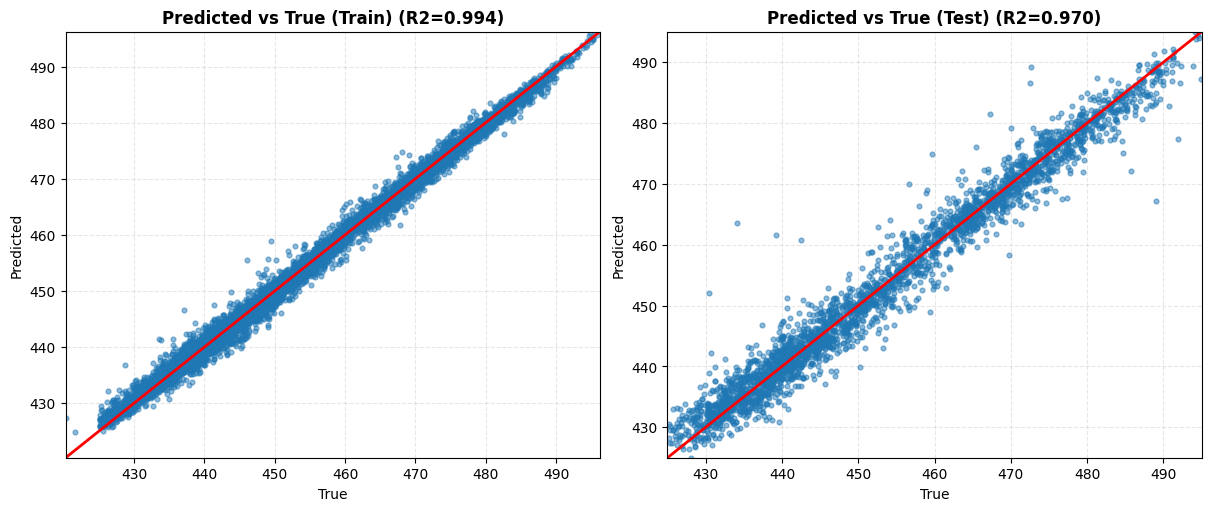

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

plot_pred_vs_true(y_train, y_pred_train, title="Predicted vs True (Train)", ax=axes[0])
plot_pred_vs_true(y_test, y_pred_test, title="Predicted vs True (Test)", ax=axes[1])

plt.show()

* `Train`: The points lie perfectly along the diagonal—minimal discrepancy, a perfect match between predicted and actual values.
* `Test`: The scatter is slightly higher, but the structure remains diagonal, with no systematic bias. Errors are random and uniform.
* For both datasets, the cloud is symmetrical and narrow -> errors are randomly distributed, with no systematic under- or overestimation.

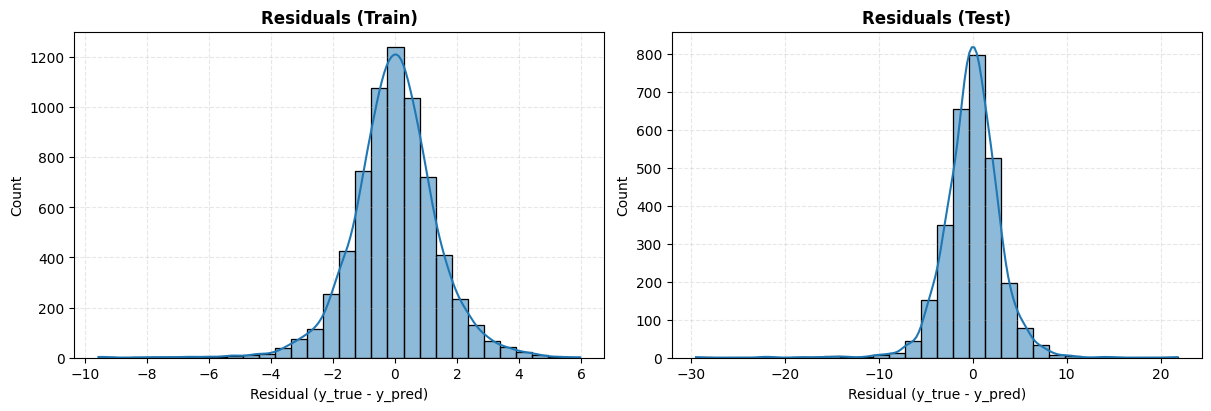

In [27]:
# Create a figure with two subplots in one row
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# Plot the histogram for Train on the left 
plot_residuals_hist(y_train, y_pred_train, title="Residuals (Train)", ax=axes[0])

# Plot the histogram for Test on the right 
plot_residuals_hist(y_test, y_pred_test, title="Residuals (Test)", ax=axes[1])

plt.show()

* `Train`: Narrow distribution with minimal variance. Most errors fall in the range of $-2$ to $+2$. There is a slight right-skew, but no severe distortion.
* `Test`: The bulk of the errors are concentrated between $-5$ and $+5$. The tails are longer, which is natural for unseen data. There is no systematic bias.
* The `Super Learner` residuals demonstrate symmetry and an absence of systematic bias.

## Conclusion

* The dataset with physical features proved to be clean, stable, and highly predictable.
* The lack of complex feature engineering is explained by the physical nature of the data: the relationships between variables already reflect the underlying patterns of the processes.
* Even simple algorithms demonstrated high quality, but the absolute leaders among the single models were the **gradient boosting** algorithms.
* The final `Super Learner` ensemble provided a maximum, production-grade level of accuracy ($97\%$) and stability with minimal preprocessing.
* However, the `Super Learner` architecture requires significant computational resources. **CatBoost** is the optimal choice among all tested algorithms, demonstrating an ideal balance between high prediction accuracy and robustness.
* Overall, the work shows that given accurate initial data, machine learning models can precisely reproduce physical dependencies without the need for additional feature engineering.